# Bio-Physical Radiant Heating — Witte et al. (2024)

**Reference:** Carson R. Witte, Ajit Subramaniam, and Christopher J. Zappa (2024).  
*An Improved Bio-Physical Parameterization for Ocean Radiant Heating in Conditions of Near-Surface Stratification.*  
JGR: Oceans, 129, e2024JC021049. https://doi.org/10.1029/2024JC021049

**Code:** https://github.com/Zappa-Lab/Bio-Physical-Radiant-Heating-Parameterization

---

## What this notebook does

Exercises the **simplified five-band parameterization** (`final_param`) from Witte et al. (2024) — the version suitable for ocean models and DWL algorithms. The functions are extracted from the Zappa-Lab toolbox and run without the external data files (spectral lookup tables) needed by the full Spectral Model.

### Figures
1. **Irradiance depth profiles** — Ed(z) for a range of chlorophyll concentrations
2. **Heating rate profiles** — –dEd/dz (W m⁻³), the source term for DWL models
3. **Scheme comparison** — Witte24 vs. Paulson & Simpson (1977), Soloviev (1982)
4. **BoB application** — Ed(z) and heating rates at typical Bay of Bengal SSRD and Chl

### Parameterization summary

Five spectral bands (UV 6%, Blue 17%, Yellow 14%, Red 14%, IR 49%) with Beer-Lambert extinction in the visible and an arctangent form for IR.
Chlorophyll-dependent Kd for UV–Red via Morel et al. (2007) power-law fits.  
Fixed albedo α = 0.045 (open-ocean, Witte et al. UAV correction to Payne 1972).

```
Ed(z) = SW*(1-α) * [Auv*exp(-Kd_UV*z) + Ab*exp(-Kd_B*z) + Ay*exp(-Kd_Y*z)
                   + Ar*exp(-Kd_R*z) + Air*exp(-C1*z)*(1 - C2*arctan(C3 + C4*z))]
```

In [1]:
# -------------------------------------------------------
# Witte et al. (2024) parameterization + classic schemes
# All functions are self-contained (pure numpy).
# Extracted from Zappa-Lab/Bio-Physical-Radiant-Heating-Parameterization
# -------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os

os.makedirs('figs', exist_ok=True)

# -------------------------------------------------------------------
# Witte et al. 2024  — simplified five-band parameterization
# -------------------------------------------------------------------
def final_param(SW, Chl, z):
    """
    Witte et al. (2024) five-band irradiance parameterization.
    Ed(z) as a function of surface SW (W/m²), chlorophyll (mg/m³), depth z (m).
    Uses fixed open-ocean albedo α = 0.045.
    """
    Auv, Ab, Ay, Ar, Air = 0.06, 0.17, 0.14, 0.14, 0.49   # waveband fractions
    alpha = 0.045                                            # open-ocean albedo
    # Chlorophyll-dependent Kd [m⁻¹] (Morel et al. 2007 power-law fits)
    Kw_UV, chi_UV, e_UV = 0.0218, 0.1758, 0.6541
    Kw_B,  chi_B,  e_B  = 0.0119, 0.1048, 0.6330
    Kw_Y,  chi_Y,  e_Y  = 0.0665, 0.0582, 0.5342
    Kw_R,  chi_R,  e_R  = 0.3608, 0.0585, 0.4723
    C1, C2, C3, C4 = 1.87, 0.47, 0.66, 30                  # IR arctangent params

    Kd_UV = Kw_UV + chi_UV * Chl**e_UV
    Kd_B  = Kw_B  + chi_B  * Chl**e_B
    Kd_Y  = Kw_Y  + chi_Y  * Chl**e_Y
    Kd_R  = Kw_R  + chi_R  * Chl**e_R

    Ed0 = SW * (1 - alpha)
    return (Ed0 * Auv * np.exp(-Kd_UV * z)
          + Ed0 * Ab  * np.exp(-Kd_B  * z)
          + Ed0 * Ay  * np.exp(-Kd_Y  * z)
          + Ed0 * Ar  * np.exp(-Kd_R  * z)
          + Ed0 * Air * np.exp(-C1 * z) * (1 - C2 * np.arctan(C3 + C4 * z)))


def heating_rate(SW, Chl, z, dz=0.01):
    """Solar heating rate [W m⁻³] = -dEd/dz, computed by finite difference."""
    return -(final_param(SW, Chl, z + dz/2) - final_param(SW, Chl, z - dz/2)) / dz


# -------------------------------------------------------------------
# Classic comparison schemes
# -------------------------------------------------------------------
def I_ps77(I0, z):
    """Paulson & Simpson (1977) 2-band, Jerlov Type I."""
    return I0 * (0.58 * np.exp(-2.86 * z) + 0.42 * np.exp(-0.043 * z))

def I_s82(I0, z):
    """Soloviev (1982) 3-band (used in COARE 3.5 DWL)."""
    return I0 * (0.45 * np.exp(-0.078 * z)
               + 0.27 * np.exp(-2.8   * z)
               + 0.28 * np.exp(-71    * z))

def I_ps81(I0, z):
    """Paulson & Simpson (1981) 9-band."""
    return I0 * (0.237  * np.exp(-0.0287 * z)
               + 0.360  * np.exp(-0.440  * z)
               + 0.179  * np.exp(-31.7   * z)
               + 0.087  * np.exp(-182    * z)
               + 0.080  * np.exp(-1200   * z)
               + 0.0246 * np.exp(-7940   * z)
               + 0.025  * np.exp(-3190   * z)
               + 0.007  * np.exp(-12800  * z)
               + 0.0004 * np.exp(-69400  * z))

print('Functions loaded: final_param, heating_rate, I_ps77, I_s82, I_ps81')

Functions loaded: final_param, heating_rate, I_ps77, I_s82, I_ps81


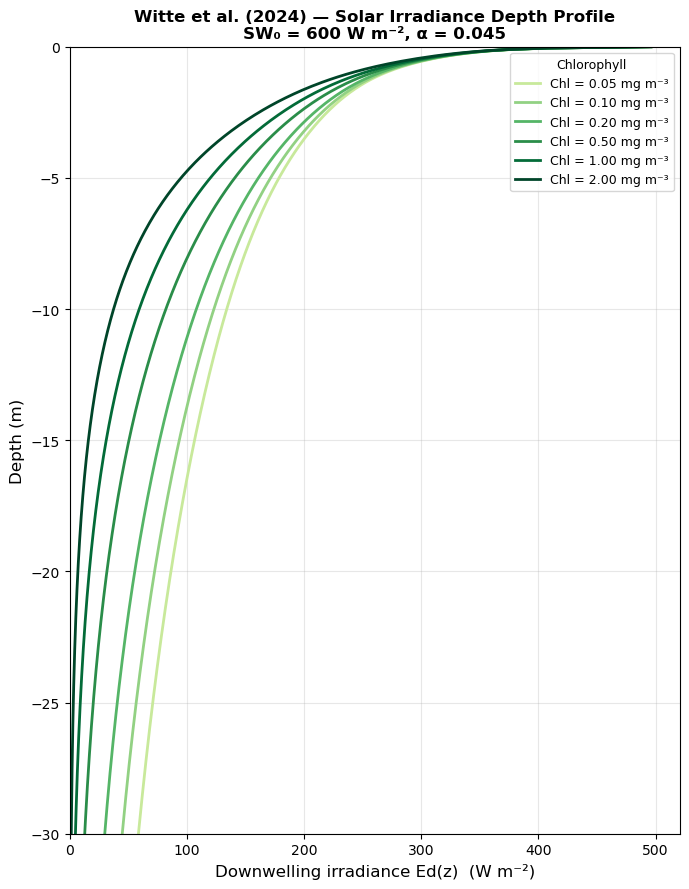

Saved figs/Witte24_depth_profiles.png


In [2]:
# -------------------------------------------------------
# Figure 1: Irradiance depth profiles at multiple Chl
# SW = 600 W/m² (clear-sky midday in BoB)
# -------------------------------------------------------
SW_ref = 600.0   # W/m²
z_arr  = np.linspace(0, 30, 600)

CHL_VALS = [0.05, 0.10, 0.20, 0.50, 1.00, 2.00]   # mg/m³
CMAP     = plt.cm.YlGn(np.linspace(0.3, 1.0, len(CHL_VALS)))

fig, ax = plt.subplots(figsize=(7, 9))

for chl, color in zip(CHL_VALS, CMAP):
    Ed = final_param(SW_ref, chl, z_arr)
    ax.plot(Ed, -z_arr, color=color, lw=2,
            label=f'Chl = {chl:.2f} mg m⁻³')

ax.set_xlabel('Downwelling irradiance Ed(z)  (W m⁻²)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_ylim(-30, 0)
ax.set_xlim(left=0)
ax.legend(fontsize=9, title='Chlorophyll', title_fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title(
    f'Witte et al. (2024) — Solar Irradiance Depth Profile\n'
    f'SW₀ = {SW_ref:.0f} W m⁻², α = 0.045',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('figs/Witte24_depth_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_depth_profiles.png')

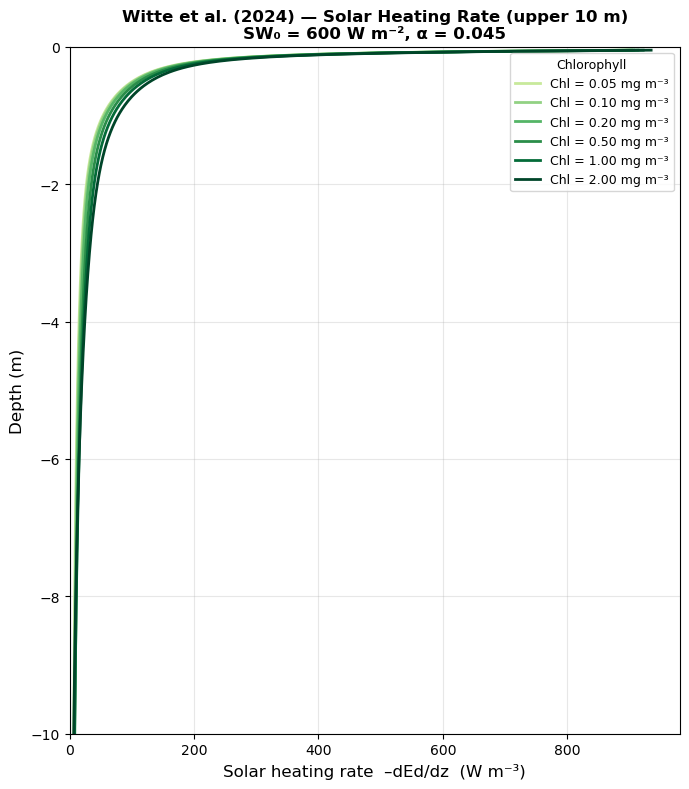

Saved figs/Witte24_heating_rate.png


In [3]:
# -------------------------------------------------------
# Figure 2: Solar heating rate = -dEd/dz (W/m³)
# This is the source term fed into DWL / mixed-layer models.
# Focus on upper 10 m where DWLs form.
# -------------------------------------------------------
z_shallow = np.linspace(0.05, 10, 500)

fig, ax = plt.subplots(figsize=(7, 8))

for chl, color in zip(CHL_VALS, CMAP):
    hr = heating_rate(SW_ref, chl, z_shallow)
    ax.plot(hr, -z_shallow, color=color, lw=2,
            label=f'Chl = {chl:.2f} mg m⁻³')

ax.set_xlabel('Solar heating rate  –dEd/dz  (W m⁻³)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_ylim(-10, 0)
ax.set_xlim(left=0)
ax.legend(fontsize=9, title='Chlorophyll', title_fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title(
    f'Witte et al. (2024) — Solar Heating Rate (upper 10 m)\n'
    f'SW₀ = {SW_ref:.0f} W m⁻², α = 0.045',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('figs/Witte24_heating_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_heating_rate.png')

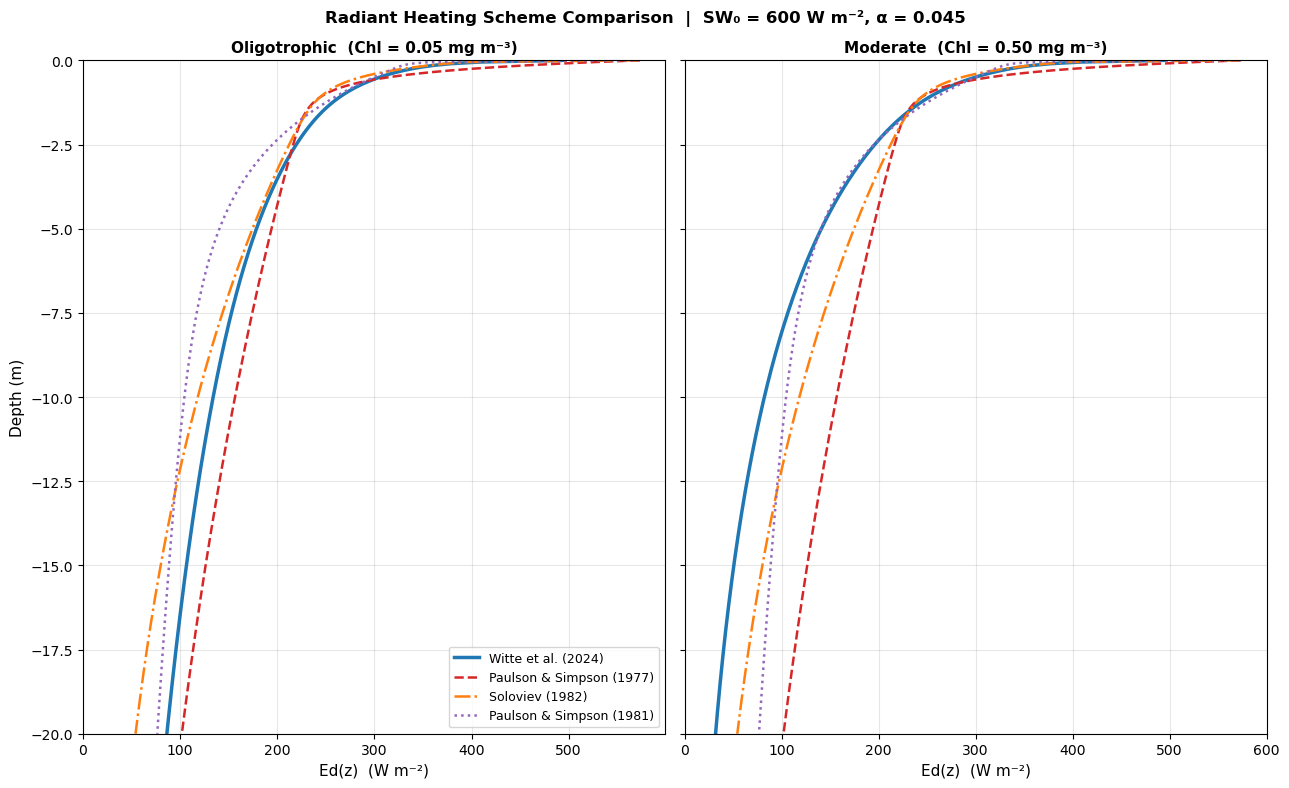

Saved figs/Witte24_scheme_comparison.png


In [4]:
# -------------------------------------------------------
# Figure 3: Scheme comparison
# Witte24 vs. Paulson & Simpson 1977, Soloviev 1982
# Two typical Chl scenarios: oligotrophic and moderate
#
# Note on input convention:
#   PS77 / S82 take I0 = net sub-surface irradiance (albedo already removed)
#   Witte24 takes SW at surface and applies α=0.045 internally
#   For fair comparison, pass I0_net = SW*(1-0.045) to the classic schemes
# -------------------------------------------------------
z_arr = np.linspace(0, 20, 400)
alpha_ref = 0.045
I0_net    = SW_ref * (1 - alpha_ref)

fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)

for ax, chl, title_chl in zip(axes,
                               [0.05, 0.50],
                               ['Oligotrophic  (Chl = 0.05 mg m⁻³)',
                                'Moderate  (Chl = 0.50 mg m⁻³)']):
    Ed_w24 = final_param(SW_ref, chl, z_arr)
    Ed_ps77 = I_ps77(I0_net, z_arr)
    Ed_s82  = I_s82(I0_net, z_arr)
    Ed_ps81 = I_ps81(I0_net, z_arr)

    ax.plot(Ed_w24,  -z_arr, color='#1f77b4', lw=2.5, label='Witte et al. (2024)')
    ax.plot(Ed_ps77, -z_arr, color='#d62728', lw=1.8, ls='--', label='Paulson & Simpson (1977)')
    ax.plot(Ed_s82,  -z_arr, color='#ff7f0e', lw=1.8, ls='-.', label='Soloviev (1982)')
    ax.plot(Ed_ps81, -z_arr, color='#9467bd', lw=1.8, ls=':',  label='Paulson & Simpson (1981)')

    ax.set_xlabel('Ed(z)  (W m⁻²)', fontsize=11)
    ax.set_xlim(left=0)
    ax.set_ylim(-20, 0)
    ax.set_title(title_chl, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Depth (m)', fontsize=11)
        ax.legend(fontsize=9, loc='lower right')

fig.suptitle(
    f'Radiant Heating Scheme Comparison  |  SW₀ = {SW_ref:.0f} W m⁻², α = {alpha_ref}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figs/Witte24_scheme_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_scheme_comparison.png')

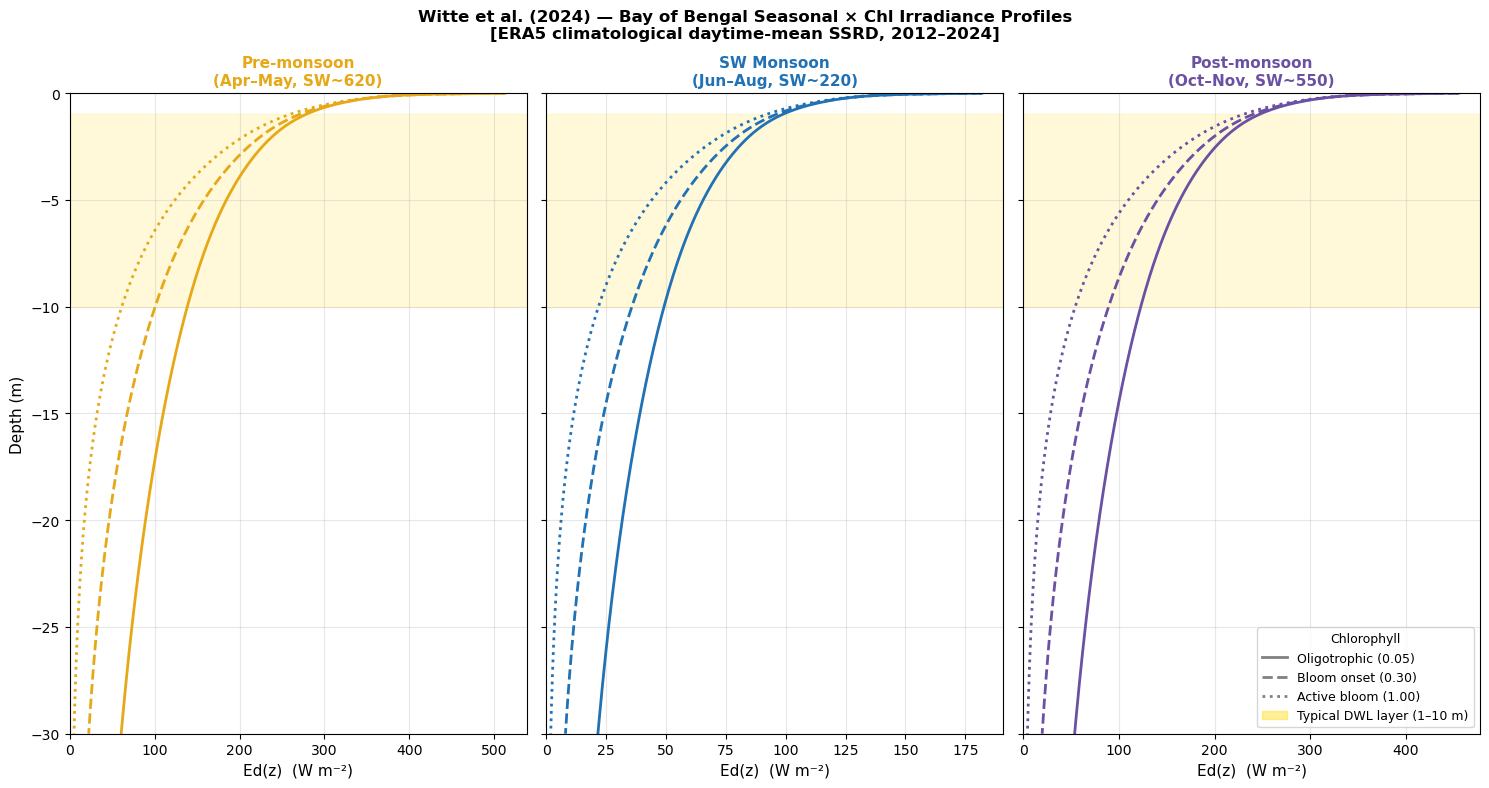

Saved figs/Witte24_BoB_application.png


In [5]:
# -------------------------------------------------------
# Figure 4: Bay of Bengal application
# Use climatological daytime-mean SSRD ranges from ERA5
# (BoB, 2012-2024) for three seasons:
#   Post-monsoon clear sky  ~ 550 W/m²  (Oct-Nov)
#   SW monsoon suppressed   ~ 220 W/m²  (Jun-Aug)
#   Pre-monsoon maximum     ~ 620 W/m²  (Apr-May)
#
# Paired with three BoB Chl scenarios:
#   Oligotrophic            ~ 0.05 mg/m³ (open BoB, post-monsoon)
#   Bloom onset             ~ 0.30 mg/m³ (mixed layer shoaling)
#   Active bloom            ~ 1.00 mg/m³ (post-cyclone / river plume)
# -------------------------------------------------------

SEASONS = {
    'Pre-monsoon\n(Apr–May, SW~620)': (620, '#e6a817'),
    'SW Monsoon\n(Jun–Aug, SW~220)':  (220, '#2171b5'),
    'Post-monsoon\n(Oct–Nov, SW~550)':(550, '#6a51a3'),
}
CHL_BOB = {'Oligotrophic (0.05)': 0.05,
            'Bloom onset (0.30)':  0.30,
            'Active bloom (1.00)': 1.00}
CHL_LS  = ['-', '--', ':']

z_arr = np.linspace(0, 30, 600)

fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True)

for ax, (season_label, (SW, col)) in zip(axes, SEASONS.items()):
    for (chl_label, chl), ls in zip(CHL_BOB.items(), CHL_LS):
        Ed = final_param(SW, chl, z_arr)
        ax.plot(Ed, -z_arr, color=col, lw=2, ls=ls, label=chl_label)

    # Annotate DWL depth range (nominally 1-10 m)
    ax.axhspan(-10, -1, color='gold', alpha=0.15, label='Typical DWL layer')

    ax.set_xlabel('Ed(z)  (W m⁻²)', fontsize=11)
    ax.set_xlim(left=0)
    ax.set_ylim(-30, 0)
    ax.set_title(season_label, fontsize=11, fontweight='bold', color=col)
    ax.grid(True, alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Depth (m)', fontsize=11)

# Shared legend on last panel
handles = [mlines.Line2D([], [], color='gray', lw=2, ls=ls, label=lbl)
           for lbl, ls in zip(CHL_BOB.keys(), CHL_LS)]
handles += [mpatches.Patch(color='gold', alpha=0.4, label='Typical DWL layer (1–10 m)')]
axes[-1].legend(handles=handles, fontsize=9, title='Chlorophyll', title_fontsize=9, loc='lower right')

fig.suptitle(
    'Witte et al. (2024) — Bay of Bengal Seasonal × Chl Irradiance Profiles\n'
    '[ERA5 climatological daytime-mean SSRD, 2012–2024]',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figs/Witte24_BoB_application.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_BoB_application.png')

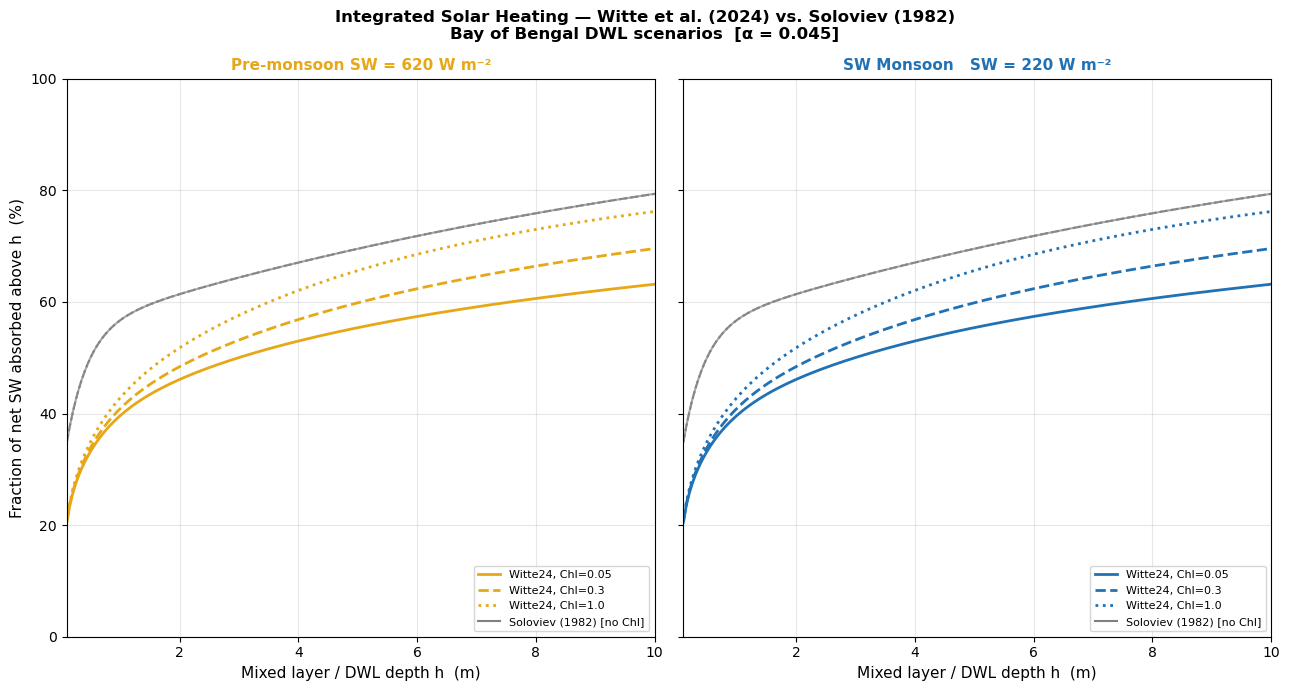

Saved figs/Witte24_integrated_heating.png


In [6]:
# -------------------------------------------------------
# Figure 5: Integrated heating in the upper mixed layer
# Q_solar(h) = Ed(0) - Ed(h) = solar heat absorbed in top h meters
# This feeds the DWL temperature tendency: dT/dt = Q_solar / (rho*cp*h)
#
# Shown as a fraction of net surface irradiance absorbed above depth h.
# Compare Witte24 vs. S82 (COARE default) for the BoB monsoon season.
# -------------------------------------------------------
rho = 1025.0   # kg/m³
cp  = 3985.0   # J/(kg K)

h_arr = np.linspace(0.1, 10, 200)   # DWL depth range
SW_m  = 220.0   # monsoon suppressed
SW_c  = 620.0   # clear sky
alpha = 0.045

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

scenarios = [
    ('Pre-monsoon SW = 620 W m⁻²', SW_c, '#e6a817'),
    ('SW Monsoon   SW = 220 W m⁻²', SW_m, '#2171b5'),
]

for ax, (label, SW, col) in zip(axes, scenarios):
    I0 = SW * (1 - alpha)
    for chl, ls in zip([0.05, 0.30, 1.00], ['-', '--', ':']):
        # fraction absorbed in top h meters
        frac_w24 = (final_param(SW, chl, 0.0) - final_param(SW, chl, h_arr)) / I0
        frac_s82 = (I_s82(I0, 0.0)            - I_s82(I0, h_arr))            / I0

        ax.plot(h_arr, frac_w24 * 100, color=col, lw=2, ls=ls,
                label=f'Witte24, Chl={chl}')
        ax.plot(h_arr, frac_s82 * 100, color='gray', lw=1.5, ls=ls, alpha=0.7)

    # Add S82 legend entry once
    ax.plot([], [], color='gray', lw=1.5, label='Soloviev (1982) [no Chl]')
    ax.set_xlabel('Mixed layer / DWL depth h  (m)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_xlim(0.1, 10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=col)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

axes[0].set_ylabel('Fraction of net SW absorbed above h  (%)', fontsize=11)

fig.suptitle(
    'Integrated Solar Heating — Witte et al. (2024) vs. Soloviev (1982)\n'
    'Bay of Bengal DWL scenarios  [α = 0.045]',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('figs/Witte24_integrated_heating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figs/Witte24_integrated_heating.png')